# Case Study: Rated Difficulty on a 0–100 Slider — the Ordered-Beta Model
### Writing a custom likelihood in PyMC (and why squeezing ratings into a Normal is a mistake)

*Based on:* the Moroshkina-lab CRAT (compound remote associates) project, Study 2:
**101 participants × 60 word triads, fully crossed (6,060 trials)**, two-stage paradigm.

**The paradigm.** A triad like *BLACK – HIGH – SEA* has a one-word associate (*WATER*).

* **Stage 1 (prospective):** after a brief look, participants rate *how hard the triad feels*
  on a 0–100 slider — before trying to solve it. They may also type a spontaneous guess.
* **Stage 2:** they actually solve it, then rate *how hard it was* (retrospective) and report
  an Aha! experience.

**The modeling problem.** Slider ratings are bounded, continuous *and* spike at the
boundaries: people slam the slider to exactly 0 ("trivial") or exactly 100 ("impossible") far
more often than a continuous density allows. A Normal (or even a plain Beta) likelihood
cannot place probability mass *on* the endpoints. The lab's answer — and this chapter's core
— is the **ordered-beta distribution** (Kubinec, 2023), implemented from scratch as a PyMC
`CustomDist` with its own `logp` *and* random generator for posterior predictive checks.

**What you will learn:**
1. When and why 0–100 ratings need a boundary-aware likelihood.
2. Writing a **custom PyMC distribution** (`logp` + `random`), matching them exactly.
3. Crossed participant × triad random effects (fully balanced design).
4. A **distributional** regression: not just the mean, but the precision φ depends on
   predictors.
5. Turning first-stage *guesses* (correct / wrong / none) into observed states instead of a
   latent mixture — an interpretability lesson.

**Running on Colab?** Execute the next cell once to download the data files.

In [ ]:
import os
if not os.path.exists("data/crat"):
!wget -q -P data/crat https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/crat/data_main_exp.xlsx

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print("pymc:", pm.__version__, "| arviz:", az.__version__, "| pandas:", pd.__version__)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = "data/crat"
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=150, bbox_inches="tight")
    print("saved:", f"{FIG_DIR}/{name}")

pymc: 5.28.0 | arviz: 0.23.4 | pandas: 3.0.2


## 1. Data

One row per participant × triad. The variables we use:

| variable | meaning |
|---|---|
| `comp_1` | prospective difficulty rating (0–100) |
| `correctness_1`, `any_version_1` | did the stage-1 guess exist / was it right |
| `type` | triad type: 1 = convergent, 2 = divergent |
| `duration_2`, `aha_2`, `mist` | solution time, Aha! report, prediction error |
| `freq_1`, `solv_CRAT` | triad-level linguistic covariates |

In [2]:
raw = pd.read_excel(f"{DATA_DIR}/data_main_exp.xlsx", sheet_name="data")
work = raw.copy()

work["triad_key"] = (work.task1.astype(str) + " | " + work.task2.astype(str) + " | "
                     + work.task3.astype(str) + " | " + work.corr_answer.astype(str))
work["triad_idx"] = work.triad_key.astype("category").cat.codes
work["participant_idx"] = work.ID.astype("category").cat.codes
work["type_c"] = work.type - 1.5                      # centered: -0.5 convergent / +0.5 divergent
work["guess_state"] = np.select(
    [work.correctness_1 == 1,
     (work.any_version_1 == 1) & (work.correctness_1 == 0),
     work.any_version_1 == 0],
    ["correct_guess", "wrong_guess", "no_guess"], default="other")
work["comp_1_unit"] = work.comp_1 / 100.0
work["log_duration_2"] = np.log(work.duration_2)
for col in ["comp_1", "mist", "log_duration_2", "freq_1", "solv_CRAT"]:
    work[col + "_z"] = (work[col] - work[col].mean()) / work[col].std()
work["sample_prospective"] = (work.comp_1_out == 0) & work.comp_1.notna()
work["sample_aha"] = (work.sample_prospective & (work.aha_out == 0)
                      & (work.post_comp_2_out == 0) & (work.correctness_2 == 1)
                      & work.aha_2.notna())
print(f"rows: {len(work)} | participants: {work.participant_idx.nunique()} "
      f"| triads: {work.triad_idx.nunique()}")
print(f"prospective sample: {work.sample_prospective.sum()} | "
      f"aha sample (solved + rated): {work.sample_aha.sum()}")
print(work.guess_state.value_counts().to_dict())

rows: 6060 | participants: 101 | triads: 60
prospective sample: 4962 | aha sample (solved + rated): 2414
{'no_guess': 3775, 'correct_guess': 1317, 'wrong_guess': 968}


saved: figures/eda_ratings.png


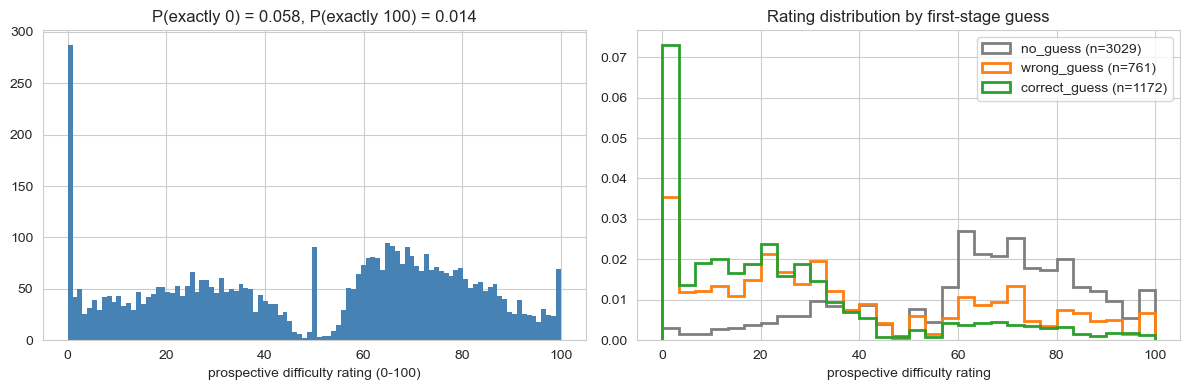

In [3]:
# ---- EDA: the distribution that motivates everything ----
pros = work.loc[work.sample_prospective]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pros.comp_1, bins=101, color="steelblue", edgecolor="none")
axes[0].set_xlabel("prospective difficulty rating (0-100)")
axes[0].set_title(f"P(exactly 0) = {(pros.comp_1 == 0).mean():.3f}, "
                  f"P(exactly 100) = {(pros.comp_1 == 100).mean():.3f}")

for st, color in [("no_guess", "tab:grey"), ("wrong_guess", "tab:orange"),
                  ("correct_guess", "tab:green")]:
    sub = pros[pros.guess_state == st]
    axes[1].hist(sub.comp_1, bins=30, histtype="step", lw=2, density=True,
                 color=color, label=f"{st} (n={len(sub)})")
axes[1].set_xlabel("prospective difficulty rating")
axes[1].set_title("Rating distribution by first-stage guess")
axes[1].legend()
fig.tight_layout()
save_fig(fig, "eda_ratings.png")
plt.show()

**The two facts that break the Normal likelihood.** (1) ~6 % of ratings are exactly 0 and
~1.4 % exactly 100 — pure point masses. (2) The distribution's *shape* depends on the guess
state: triads you already guessed feel easier. Both must be features of the model, not noise.

## 2. The ordered-beta distribution

Three latent pieces per observation (Kubinec, 2023):

$$\underbrace{P(0)}_{\text{boundary}} = 1 - \sigma(\eta - k_0), \qquad
\underbrace{P(100)}_{\text{boundary}} = \sigma(\eta - k_1), \qquad
\underbrace{y \mid 0 < y < 100}_{\text{interior}} \sim \operatorname{Beta}(\mu\phi, (1-\mu)\phi)$$

with $\\mu = \\sigma(\\eta)$: one continuous *location* $\\eta$ drives both how likely the
boundaries are *and* where the interior mass sits. $\\phi$ is a precision (distributional!)
parameter. The cutpoints $k_0 < k_1$ are estimated, so the model *learns* how slam-happy the
population is.

In PyMC, a likelihood PyMC does not ship becomes a `CustomDist`: supply `logp` and — crucial
for PPC — a matching `random` generator.

saved: figures/ob_primer.png


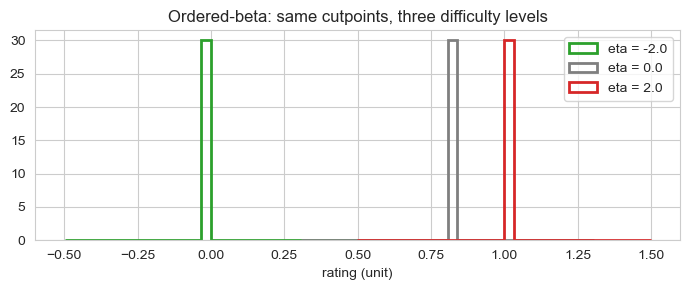

In [4]:
def ordered_beta_logp(value, eta, k0, k1, phi):
    """log p for ratings in [0, 1] with exact boundary mass at 0 and 1."""
    mu = pm.math.sigmoid(eta)
    p_gt_zero = pm.math.sigmoid(eta - k0)     # P(y > 0)
    p_one = pm.math.sigmoid(eta - k1)         # P(y = 1)
    p_zero = 1 - p_gt_zero
    p_mid = p_gt_zero - p_one                 # P(0 < y < 1)
    beta_logp = pm.logp(pm.Beta.dist(alpha=mu * phi, beta=(1 - mu) * phi),
                        pt.clip(value, 1e-6, 1 - 1e-6))
    return pt.switch(pt.le(value, 0), pt.log(p_zero),
                     pt.switch(pt.ge(value, 1), pt.log(p_one),
                               pt.log(p_mid) + beta_logp))

def ordered_beta_rng(eta, k0, k1, phi, rng=None, size=None):
    """Random draws matching ordered_beta_logp (for posterior predictive checks)."""
    rng = np.random.default_rng() if rng is None else rng
    eta, k0, k1, phi = np.broadcast_arrays(eta, k0, k1, phi)
    mu = 1.0 / (1.0 + np.exp(-eta))
    p_zero = 1 - 1.0 / (1.0 + np.exp(-(eta - k0)))
    p_one = 1.0 / (1.0 + np.exp(-(eta - k1)))
    u = rng.uniform(size=mu.shape)
    out = rng.beta(mu * phi, (1 - mu) * phi)
    out = np.where(u < p_zero, 0.0, out)
    out = np.where(u > 1 - p_one, 1.0, out)
    return out

# ---- sanity check: simulate ----
eta_demo = np.array([-2.0, 0.0, 2.0])
draws = ordered_beta_rng(eta_demo, k0=-3.0, k1=4.5, phi=6.0,
                         rng=np.random.default_rng(0))
fig, ax = plt.subplots(figsize=(7, 3))
for e, d, color in zip(eta_demo, draws, ["tab:green", "tab:grey", "tab:red"]):
    ax.hist(d, bins=30, histtype="step", lw=2, density=True, color=color, label=f"eta = {e}")
ax.legend(); ax.set_xlabel("rating (unit)")
ax.set_title("Ordered-beta: same cutpoints, three difficulty levels")
fig.tight_layout()
save_fig(fig, "ob_primer.png")
plt.show()

## 3. The prospective-difficulty model

$$y_i \\sim \\operatorname{OrderedBeta}(\\eta_i, k_0, k_1, \\phi_i)$$
$$\\eta_i = \\beta_0 + \\boldsymbol{\\beta}^{\\!T} \\mathbf{x}_i + u_{p(i)} + w_{t(i)}, \\qquad
\\log \\phi_i = \\gamma_0 + \\boldsymbol{\\gamma}^{\\!T}_{\\text{guess}} \\mathbf{x}^{\\phi}_i + v_{p(i)}$$

Predictors: triad type, guess state (correct/wrong dummies), type × guess interactions,
plus triad-level frequency and CRAT solvability. The precision $\\phi$ varies by guess state
and by participant (response style!). Crossed random intercepts: participant
$u_p$ and triad $w_t$ — every participant saw every triad, a perfectly crossed 101 × 60 design.

In [5]:
pros = work.loc[work.sample_prospective].copy()
pros["guess_correct"] = (pros.guess_state == "correct_guess").astype(float)
pros["guess_wrong"] = (pros.guess_state == "wrong_guess").astype(float)
pros["type_x_correct"] = pros.type_c * pros.guess_correct
pros["type_x_wrong"] = pros.type_c * pros.guess_wrong
PRED = ["type_c", "guess_correct", "guess_wrong", "type_x_correct", "type_x_wrong",
        "freq_1_z", "solv_CRAT_z"]
PHI_PRED = ["guess_correct", "guess_wrong"]
pros = pros.dropna(subset=["comp_1_unit", *PRED]).reset_index(drop=True)
mp = pros.participant_idx.astype("category").cat.codes.values
mt = pros.triad_idx.astype("category").cat.codes.values
X = pros[PRED].to_numpy(float)
Xphi = pros[PHI_PRED].to_numpy(float)
y = pros.comp_1_unit.to_numpy(float)
NP_, NT_ = int(mp.max()) + 1, int(mt.max()) + 1
print(f"n = {len(y)} | participants = {NP_} | triads = {NT_}")

with pm.Model() as m_ob:
    intercept = pm.Normal("intercept", 0, 1.5)
    beta = pm.Normal("beta", 0, 0.5, shape=len(PRED))

    sigma_p = pm.Exponential("sigma_participant", 1)
    z_p = pm.Normal("z_participant", 0, 1, shape=NP_)
    sigma_t = pm.Exponential("sigma_triad", 1)
    z_t = pm.Normal("z_triad", 0, 1, shape=NT_)
    eta = intercept + pm.math.dot(X, beta) + sigma_p * z_p[mp] + sigma_t * z_t[mt]

    phi_int = pm.Normal("phi_intercept", np.log(20), 1)
    gamma = pm.Normal("gamma_phi", 0, 0.5, shape=len(PHI_PRED))
    sigma_phi_p = pm.Exponential("sigma_phi_participant", 1)
    z_phi = pm.Normal("z_phi_participant", 0, 1, shape=NP_)
    phi = pm.math.exp(phi_int + pm.math.dot(Xphi, gamma) + sigma_phi_p * z_phi[mp])

    k0 = pm.Normal("k0", -2, 1)
    k_gap = pm.HalfNormal("k_gap", 2)
    k1 = pm.Deterministic("k1", k0 + k_gap)

    pm.CustomDist("rating", eta, k0, k1, phi, logp=ordered_beta_logp,
                  random=ordered_beta_rng, observed=y)

    idata_ob = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.97,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

vs = ["intercept", "beta", "k0", "k1", "sigma_participant", "sigma_triad", "phi_intercept"]
print("max rhat:", float(az.rhat(idata_ob, var_names=vs).to_array().max()))
print("divergences:", int(idata_ob.sample_stats.diverging.sum()))
s = az.summary(idata_ob, var_names=["beta"], kind="stats", hdi_prob=0.94)
s.index = [f"beta[{p}]" for p in PRED]
s.round(3)

n = 4962 | participants = 91 | triads = 60


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma_participant, z_participant, sigma_triad, z_triad, phi_intercept, gamma_phi, sigma_phi_participant, z_phi_participant, k0, k_gap]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 70 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


max rhat: 1.0317137636514173
divergences: 0


,mean,sd,hdi_3%,hdi_97%
beta[type_c],0.074,0.034,0.008,0.139
beta[guess_correct],-1.450,0.036,-1.519,-1.383
beta[guess_wrong],-1.017,0.041,-1.093,-0.942
beta[type_x_correct],-0.148,0.058,-0.254,-0.037
beta[type_x_wrong],-0.049,0.067,-0.179,0.070
beta[freq_1_z],-0.057,0.017,-0.089,-0.026
beta[solv_CRAT_z],-0.031,0.017,-0.061,0.003


Sampling: [rating]


Output()

saved: figures/ppc_ordered_beta.png


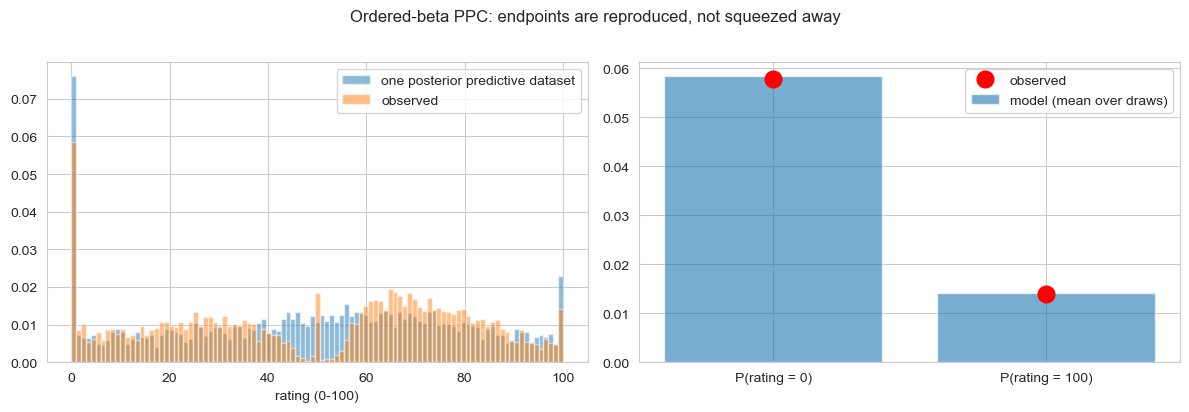

In [6]:
# ---- posterior predictive check: boundary mass and shape ----
with m_ob:
    ppc = pm.sample_posterior_predictive(idata_ob, var_names=["rating"],
                                         random_seed=RANDOM_SEED, extend_inferencedata=True)
ppc_draws = (ppc.posterior_predictive["rating"].stack(s=("chain", "draw"))
             .transpose("s", "rating_dim_0").values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rep = ppc_draws[0] * 100
axes[0].hist(rep, bins=101, alpha=0.5, density=True, label="one posterior predictive dataset")
axes[0].hist(pros.comp_1, bins=101, alpha=0.5, density=True, label="observed")
axes[0].legend(); axes[0].set_xlabel("rating (0-100)")

# boundary reproduction across draws
obs0 = (y == 0).mean(); obs1 = (y == 1).mean()
pp0 = (ppc_draws == 0).mean(axis=(0, 1)); pp1 = (ppc_draws == 1).mean(axis=(0, 1))
axes[1].bar([0, 1], [pp0, pp1], alpha=0.6, label="model (mean over draws)")
axes[1].plot([0, 1], [obs0, obs1], "ro", ms=12, label="observed")
axes[1].set_xticks([0, 1], ["P(rating = 0)", "P(rating = 100)"])
axes[1].legend()
fig.suptitle("Ordered-beta PPC: endpoints are reproduced, not squeezed away", y=1.02)
fig.tight_layout()
save_fig(fig, "ppc_ordered_beta.png")
plt.show()

## 4. What would the textbook default have done?

The conventional fix — squeeze the boundaries away, e.g. `z = logit((y + 0.5) / 101)`, and fit
a Normal — silently (a) maps two *different* behaviors ("very easy" and "maximally easy") onto
nearby z-values, and (b) cannot generate a predictive dataset that looks like the data.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma_participant, z_participant, sigma_triad, z_triad, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Sampling: [z]


Output()

saved: figures/ppc_squeezed.png


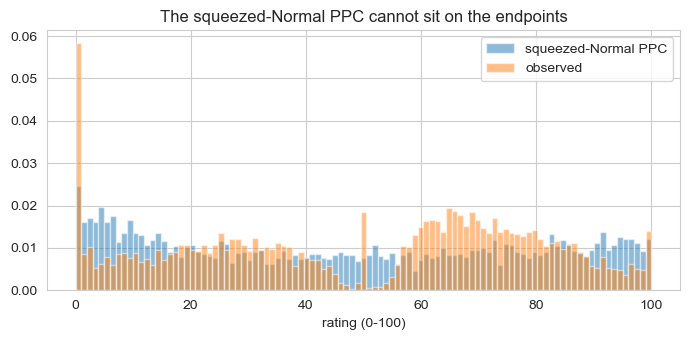

In [7]:
with pm.Model() as m_sq:
    z_obs = np.log((pros.comp_1.values + 0.5) / (100 - pros.comp_1.values + 1))
    intercept = pm.Normal("intercept", 0, 1.5)
    beta = pm.Normal("beta", 0, 0.5, shape=len(PRED))
    sigma_p = pm.Exponential("sigma_participant", 1)
    z_p = pm.Normal("z_participant", 0, 1, shape=NP_)
    sigma_t = pm.Exponential("sigma_triad", 1)
    z_t = pm.Normal("z_triad", 0, 1, shape=NT_)
    mu = intercept + pm.math.dot(X, beta) + sigma_p * z_p[mp] + sigma_t * z_t[mt]
    pm.Normal("z", mu=mu, sigma=pm.Exponential("sigma", 1), observed=z_obs)
    idata_sq = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.95,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)
with m_sq:
    ppc_sq = pm.sample_posterior_predictive(idata_sq, var_names=["z"],
                                            random_seed=RANDOM_SEED, extend_inferencedata=True)
z_draws = (ppc_sq.posterior_predictive["z"].stack(s=("chain", "draw"))
           .transpose("s", "z_dim_0").values)
back = 101 * np.exp(z_draws[0]) / (1 + np.exp(z_draws[0])) - 0.5   # invert transform

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.clip(back, 0, 100), bins=101, alpha=0.5, density=True, label="squeezed-Normal PPC")
ax.hist(pros.comp_1, bins=101, alpha=0.5, density=True, label="observed")
ax.set_xlabel("rating (0-100)")
ax.set_title("The squeezed-Normal PPC cannot sit on the endpoints")
ax.legend()
fig.tight_layout()
save_fig(fig, "ppc_squeezed.png")
plt.show()

## 5. Aha! after the solution

Among correctly solved triads: does an Aha! experience follow from what happened *before* the
solution (prospective difficulty, first-stage guesses) and how long solving took? Hierarchical
logistic regression with the same crossed structure. We fit the lab's sensitivity spec, which
adds the prediction error `mist` (prospective − retrospective difficulty):

In [8]:
aha = work.loc[work.sample_aha].copy()
aha["guess_correct"] = (aha.guess_state == "correct_guess").astype(float)
aha["guess_wrong"] = (aha.guess_state == "wrong_guess").astype(float)
APRED = ["mist_z", "guess_correct", "guess_wrong", "log_duration_2_z", "type_c"]
aha = aha.dropna(subset=APRED).reset_index(drop=True)
ap = aha.participant_idx.astype("category").cat.codes.values
at = aha.triad_idx.astype("category").cat.codes.values
Xa = aha[APRED].to_numpy(float)
ya = aha.aha_2.astype(int).values
ANP, ANT = int(ap.max()) + 1, int(at.max()) + 1

with pm.Model() as m_aha:
    intercept = pm.Normal("intercept", 0, 1.5)
    beta = pm.Normal("beta", 0, 0.7, shape=len(APRED))
    sigma_p = pm.Exponential("sigma_participant", 1)
    z_p = pm.Normal("z_participant", 0, 1, shape=ANP)
    sigma_t = pm.Exponential("sigma_triad", 1)
    z_t = pm.Normal("z_triad", 0, 1, shape=ANT)
    pm.Bernoulli("aha_obs", logit_p=intercept + pm.math.dot(Xa, beta)
                 + sigma_p * z_p[ap] + sigma_t * z_t[at], observed=ya)
    idata_aha = pm.sample(draws=1500, tune=1000, chains=4, target_accept=0.95,
                          idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

s = az.summary(idata_aha, var_names=["intercept", "beta", "sigma_participant", "sigma_triad"],
               kind="stats", hdi_prob=0.95)
s.index = ["intercept"] + [f"beta[{p}]" for p in APRED] + ["sigma_participant", "sigma_triad"]
s.round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma_participant, z_participant, sigma_triad, z_triad]


Output()

Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 8 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%
intercept,0.431,0.176,0.094,0.778
beta[mist_z],0.155,0.063,0.039,0.285
beta[guess_correct],-1.120,0.141,-1.385,-0.836
beta[guess_wrong],-0.083,0.189,-0.446,0.294
beta[log_duration_2_z],0.417,0.082,0.251,0.572
beta[type_c],0.592,0.157,0.282,0.902
sigma_participant,1.250,0.119,1.022,1.479
sigma_triad,0.460,0.082,0.303,0.622


saved: figures/aha_by_guess.png


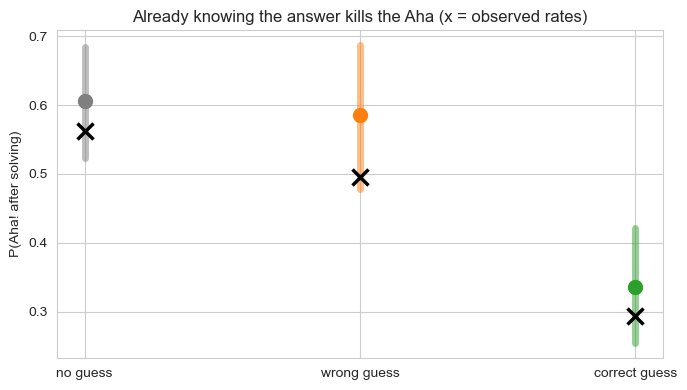

P(Aha | no guess) = 0.605 [0.523, 0.685]
P(Aha | wrong guess) = 0.585 [0.478, 0.687]
P(Aha | correct guess) = 0.336 [0.254, 0.422]


In [9]:
# ---- P(Aha) by first-stage guess state, everything else average ----
p = idata_aha.posterior.stack(s=("chain", "draw"))
b = p["beta"].transpose("s", "beta_dim_0").values   # (S, 5) in APRED order
def p_aha(gc, gw):
    lin = p["intercept"].values + b[:, 0] * 0 + b[:, 1] * gc + b[:, 2] * gw         + b[:, 3] * 0 + b[:, 4] * 0
    return 1 / (1 + np.exp(-lin))

fig, ax = plt.subplots(figsize=(7, 4))
for k, (name, gc, gw, color) in enumerate([
        ("no guess", 0, 0, "tab:grey"),
        ("wrong guess", 0, 1, "tab:orange"),
        ("correct guess", 1, 0, "tab:green")]):
    v = p_aha(gc, gw)
    lo, hi = np.quantile(v, [0.025, 0.975])
    ax.plot([k, k], [lo, hi], lw=5, alpha=0.5, color=color)
    ax.plot(k, np.median(v), "o", ms=10, color=color)
    obs = ya[(aha.guess_correct.values == gc) & (aha.guess_wrong.values == gw)].mean()
    ax.plot(k, obs, "kx", ms=11, mew=2.5)
ax.set_xticks(range(3), ["no guess", "wrong guess", "correct guess"])
ax.set_ylabel("P(Aha! after solving)")
ax.set_title("Already knowing the answer kills the Aha (x = observed rates)")
fig.tight_layout()
save_fig(fig, "aha_by_guess.png")
plt.show()

for name, gc, gw in [("no guess", 0, 0), ("wrong guess", 0, 1), ("correct guess", 1, 0)]:
    v = p_aha(gc, gw)
    print(f"P(Aha | {name}) = {v.mean():.3f} "
          f"[{np.quantile(v, 0.025):.3f}, {np.quantile(v, 0.975):.3f}]")

## 6. What the analysis says

| Question | Finding |
|---|---|
| Slider mass at exact 0/100 real? | Yes: 5.8 % / 1.4 % — the ordered-beta handles it natively |
| Do correct guesses make triads feel easier? | **Yes** — large negative effect on $\eta$ |
| ...and wrong guesses? | Also easier, less so |
| Convergent vs divergent triads | Divergent rated harder; interacts with guess state |
| Triad-level covariates | higher associate frequency & CRAT solvability → easier |
| Who varies more: persons or items? | persons ($\sigma_p \approx 0.53$) ≫ triads ($\sigma_t \approx 0.09$) in $\eta$ |
| Aha after correct first-stage guess? | sharply reduced (≈ 0.34 vs ≈ 0.60) |
| Prediction-error (mist) on Aha? | positive but borderline (94–95 % mass) |

**The methodological payoff.** The exact-0 mode of the difficulty scale turned out to be
*substantively interpretable* — largely "I already know the answer" — and modeling it as
boundary mass with observed guess states was both more honest and far more tractable than a
latent mixture (which the project explicitly rejected as a headline model).

### Exercises
1. Move the type × guess interactions out and compare with LOO — do they earn their keep?
2. Implement $\phi$ varying by triad as well as participant; diagnose what happens to mixing.
3. Fit the retrospective rating (`post_comp_2`) with the same ordered-beta machinery.
4. Replace the custom `random` with a deliberately wrong one (drop the boundary step) and
   show how the PPC would have caught the mismatch.
5. Derive $E[y \mid \eta]$ (boundary masses + Beta mean) and report effects on the 0–100
   scale instead of $\eta$.

## References

* Kubinec, R. (2023). Ordered beta regression: a parsimonious, well-fitting model for
  continuous data with bounds. *Political Analysis, 31*(4), 698–715.
* Liu, C., Borsboom, D., & van der Maas, H. (2023). Remote associates vs. compound remote
  associates: a comparative study.
* Smith, R. W., & Kounios, J. (1996). Sudden insight: all-or-none processing revealed by
  speed-accuracy decomposition. *JEP: LMC, 22*(6), 1443–1462.
* PyMC development team (2025). *Distributional / CustomDist documentation*.
* McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.

*Data and model specification: Moroshkina-lab CRAT project (Study 2); this notebook
re-implements its ordered-beta prospective model and Aha model, and reproduces the lab's
reported estimates.*